## Main

In [1]:
#| default_exp mass.massmain_module

In [7]:
#| export
from anthropmass.mass.measurements_heights_module import *
from anthropmass.mass.com_calculation_module import *
from anthropmass.mass.volume_calculation_module import *
from anthropmass.mass.plot_body_module import *
from anthropmass.mass.massclauser_module import *

In [8]:
def main(Ansur, inputweight, inputheight):
    # Define the Ansur data array
    #Ansur = [10027, 266, 1467, 337, 222, 1347, 253, 202, 401, 369, 274, 493, 71, 319, 291, 142,
    #         979, 240, 882, 619, 509, 373, 1535, 291, 1074, 259, 1292, 877, 607, 351, 36, 71, 19,
     #        247, 802, 101, 273, 349, 299, 575, 477, 1136, 90, 214, 193, 150, 583, 206, 326, 70,
      #       332, 366, 1071, 685, 422, 441, 502, 560, 500, 77, 391, 118, 400, 436, 1447, 113, 437,
       ##     919, 1700, 501, 329, 933, 240, 440, 1054, 815, 175, 853, 'Male', '4-Oct-10', 'Fort Hood',
         #    'Regular Army', 'Combat Arms', '19D', 'North Dakota', 1, 1, 41, 71, 180, 'Right hand']

    # Compute measurements, heights, volumes, and COM points
    measurements = get_measurements(Ansur, inputheight)
    heights = get_heights(Ansur, inputheight)
    volumes = get_volumes(Ansur, inputheight)
    com = get_com(Ansur, inputheight)
    weights = clauser(Ansur.iloc[0], inputweight, inputheight)




      # Limb segments
    densities = {
      "densHand":      weights["mH"]   / volumes["vH"],
      "densForearm":   weights["mLA"]  / volumes["vLA"],
      "densUpperArm":  weights["mUA"]  / volumes["vUA"],
      "densFoot":      weights["mF"]   / volumes["vF"],
      "densShank":     weights["mS"]   / volumes["vS"],
      "densThigh":     weights["mTh"]  / volumes["vT"],
      "densHead":      weights["mHe"]  / volumes["vHe"],
      "densTrunk":     weights["mTr"]  / (volumes["vUT"] + volumes["vMT"] + volumes["vLT"]),
      "densBodyTotal": weights["mTOT"] / volumes["vTOT"]
     }


    heights = heights.iloc[0]



    #Calculate weight from regression model:


    # Print results from volume estimation
    
    print("RESULTS:")
    print("Total Estimated Weight (kg) (only with Volume model using 1000kg/m3):", volumes["vTOT"] * 1000)
    print("Total Estimated Weight (kg) using regression model",weights['mTOT'] )
    print("Actual Weight (kg):", inputweight)
    # Actual height is given in the Ansur list (index 75) in meters
    actual_height = inputheight
    print("Estimated Height (m):", heights["TotalH"])
    # or another computed value
    print("Actual Height (m):", actual_height/1000)



    # Print results from regression model
    """""
    print('############################')
    print(f"Weight actual: {results['Weight_actual']:.2f} Kg")
    print(f"Weight estimated: {results['Weight_estimated']:.2f} Kg")
    
    print(f"Hand mass: {results['Hand_mass']:.2f} Kg")
    print(f"Forearm mass: {results['Forearm_mass']:.2f} Kg")
    print(f"Upperarm mass: {results['Upperarm_mass']:.2f} Kg")
    print(f"Foot mass: {results['Foot_mass']:.2f} Kg")
    print(f"Shank mass: {results['Shank_mass']:.2f} Kg")
    print(f"Thigh mass: {results['Thigh_mass']:.2f} Kg")
    print(f"Head mass: {results['Head_mass']:.2f} Kg")
    print(f"Trunk mass: {results['Trunk_mass']:.2f} Kg")

    print(f"diff %: {results['diff_percent']:.2f}")
    print(f"diff kg: {results['diff_kg']:.2f}")
    """
    # Draw the plot
    plot_body(Ansur, inputheight)

    
    


In [9]:
from anthropmass.prediction_module import *
import pandas as pd
train=pd.read_csv('../data/processed/ANSURIInormalizedtrain.csv')
y_train=train.iloc[:,1:94].drop('weightkg',axis=1).drop('stature',axis=1)
variables = y_train.columns[:]



In [10]:
def make_a_man(weight, height, gender):
    df = make_predictions('xgboost',variables, weight, height, gender)
    main(df, weight, height)
    

RESULTS:
Total Estimated Weight (kg) (only with Volume model using 1000kg/m3): 79.3367681035973
Total Estimated Weight (kg) using regression model 84.17013560257122
Actual Weight (kg): 80
Estimated Height (m): 1.810859203338623
Actual Height (m): 1.8


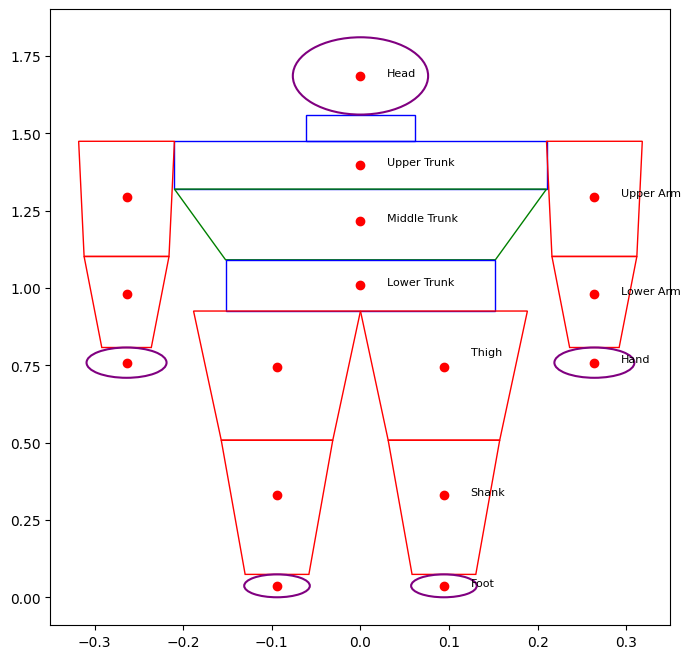

In [11]:
make_a_man(80,1800,1)

RESULTS:
Total Estimated Weight (kg) (only with Volume model using 1000kg/m3): 45.9080898457943
Actual Weight (kg): 40
Estimated Height (m): 1.6456761360168457
Actual Height (m): 1600


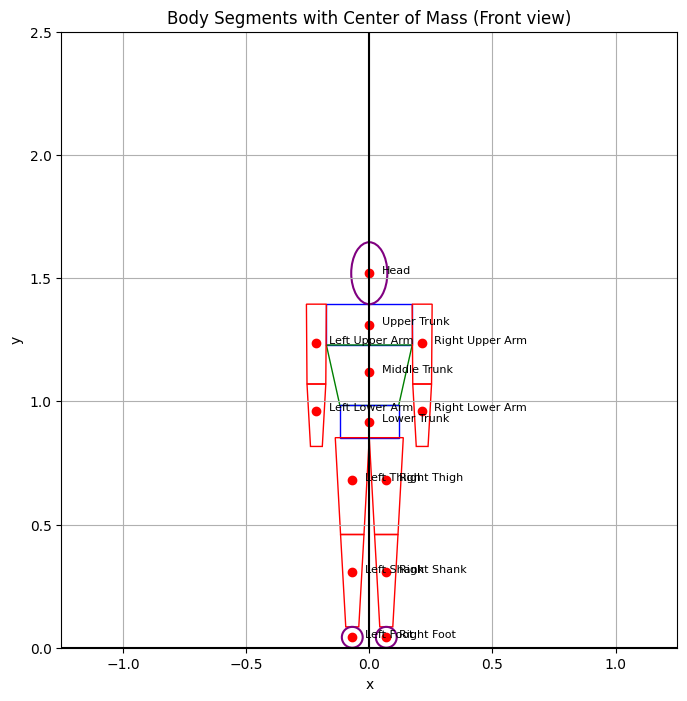

In [13]:
make_a_man(40,1600,1)